<a href="https://colab.research.google.com/github/Crazyrenan/Associative-Rule-Symptoms-Disease/blob/main/Lomba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
!pip install kagglehub[pandas-datasets] tensorflow scikit-learn matplotlib opencv-python pandas numpy

In [45]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import DenseNet121, EfficientNetB3, ConvNeXtTiny
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, average_precision_score, recall_score
import kagglehub

In [46]:
path = kagglehub.dataset_download("usmanshams/tbx-11")

print("Path dataset yang diunduh:", path)
image_dir = os.path.join(path, "TBX11K", "imgs")

if os.path.exists(image_dir):
    print(f"Direktori Ditemukan: {image_dir}")
    print("Isi folder imgs:", os.listdir(image_dir))
else:
    print("Direktori TIDAK ditemukan. Menjalankan debug struktur...")
    # List isi folder root untuk verifikasi manual
    print("Isi root dataset:", os.listdir(path))

Using Colab cache for faster access to the 'tbx-11' dataset.
Path dataset yang diunduh: /kaggle/input/tbx-11
Direktori Ditemukan: /kaggle/input/tbx-11/TBX11K/imgs
Isi folder imgs: ['tb', 'health', 'extra', 'test', 'sick']


In [47]:
image_dir = "/root/.cache/kagglehub/datasets/usmanshams/tbx-11/versions/1/TBX11K/imgs"

# Verifikasi keberadaan folder kelas
if os.path.exists(image_dir):
    print("Direktori Ditemukan!")
    print("Folder kelas yang tersedia:", os.listdir(image_dir))
else:
    print("Direktori masih tidak ditemukan. Pastikan cell kagglehub.dataset_download sudah dijalankan.")

Direktori Ditemukan!
Folder kelas yang tersedia: ['health', 'tb', 'test', 'extra', 'sick']


In [48]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
class_names = ['health', 'tb']

train_ds = tf.keras.utils.image_dataset_from_directory(
    image_dir,
    labels='inferred',
    label_mode='binary',
    class_names=class_names,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    image_dir,
    labels='inferred',
    label_mode='binary',
    class_names=class_names,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Optimasi performa loading data
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 4600 files belonging to 2 classes.
Using 3680 files for training.
Found 4600 files belonging to 2 classes.
Using 920 files for validation.


In [49]:
def build_densenet():
    inputs = layers.Input(shape=(224, 224, 3))

    # Base model menggunakan pre-trained ImageNet
    base_model = DenseNet121(include_top=False, weights='imagenet', input_tensor=inputs)
    base_model.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    return model, base_model

model, base_model = build_densenet()

In [50]:
def scheduler(epoch, lr):
    if epoch < 5:
        return 1e-5
    else:
        return lr * tf.math.exp(-0.1)

lr_callback = tf.keras.callbacks.LearningRateScheduler(scheduler)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

lr_scheduler = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

In [51]:
neg_count = 0
pos_count = 0
for _, labels in train_ds:
    labels_np = labels.numpy()
    pos_count += np.sum(labels_np == 1)
    neg_count += np.sum(labels_np == 0)

total = neg_count + pos_count
weight_for_0 = (1 / neg_count) * (total / 2.0)
weight_for_1 = (1 / pos_count) * (total / 2.0)

class_weight = {0: weight_for_0, 1: weight_for_1}

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weight,
    callbacks=[early_stopping, lr_scheduler]
)

Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 77s 420ms/step - accuracy: 0.5802 - auc: 0.6531 - loss: 0.8893 - val_accuracy: 0.5370 - val_auc: 0.7741 - val_loss: 0.7223 - learning_rate: 1.0000e-05
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 25s 219ms/step - accuracy: 0.5958 - auc: 0.7043 - loss: 0.8070 - val_accuracy: 0.5913 - val_auc: 0.7819 - val_loss: 0.6835 - learning_rate: 1.0000e-05
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 23s 197ms/step - accuracy: 0.6118 - auc: 0.7361 - loss: 0.7581 - val_accuracy: 0.6272 - val_auc: 0.7957 - val_loss: 0.6602 - learning_rate: 1.0000e-05
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 42s 205ms/step - accuracy: 0.6022 - auc: 0.7376 - loss: 0.7730 - val_accuracy: 0.6478 - val_auc: 0.8186 - val_loss: 0.6434 - learning_rate: 1.0000e-05
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 29s 248ms/step - accuracy: 0.6171 - auc: 0.7555 - loss: 0.7389 - val_accuracy: 0.6674 - val_auc: 0.8444 - val_loss: 0.6267 - learning_rate: 1.0000e-05
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 23s 2

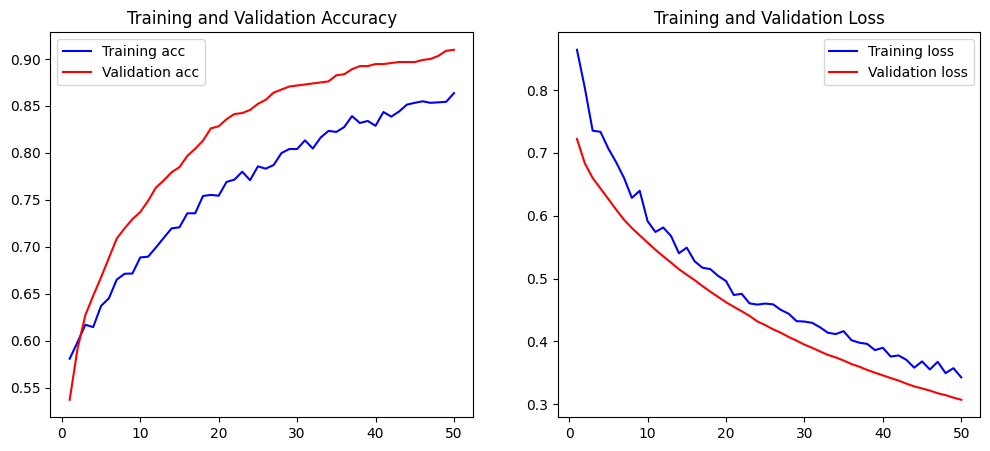

In [52]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Training acc')
    plt.plot(epochs, val_acc, 'r', label='Validation acc')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()

plot_history(history)

In [53]:
y_true = []
y_pred_probs = []

for images, labels in val_ds:
    y_true.extend(labels.numpy().flatten())
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds.flatten())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)


threshold = 0.4
y_pred_classes = (y_pred_probs > threshold).astype(int)



tn, fp, fn, tp = confusion_matrix(y_true, y_pred_classes).ravel()

accuracy = accuracy_score(y_true, y_pred_classes)
auc = roc_auc_score(y_true, y_pred_probs)
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
avg_precision = average_precision_score(y_true, y_pred_probs)
f1 = 2 * (tp / (2 * tp + fp + fn))

print(f"--- EVALUASI MODEL (Threshold: {threshold}) ---")
print(f"F1-Score     : {f1:.4f}")
print(f"Accuracy     : {accuracy:.4f}")
print(f"AUC          : {auc:.4f}")
print(f"Sensitivity  : {sensitivity:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"Avg Precision: {avg_precision:.4f}")


--- EVALUASI MODEL ---
F1-Score: 0.6508
Accuracy: 0.7924
AUC: 0.9752
Sensitivity: 0.9834
Specificity: 0.7456
Avg Precision: 0.9197


In [57]:
def get_gradcam(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_channel = preds[:, 0]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def plot_gradcam(img_path, heatmap):
    img = cv2.imread(img_path)
    img = cv2.resize(img, IMG_SIZE)

    heatmap = np.uint8(255 * heatmap)
    jet = plt.colormaps['jet']
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = cv2.resize(jet_heatmap, (img.shape[1], img.shape[0]))

    superimposed_img = jet_heatmap * 0.4 + img
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.show()

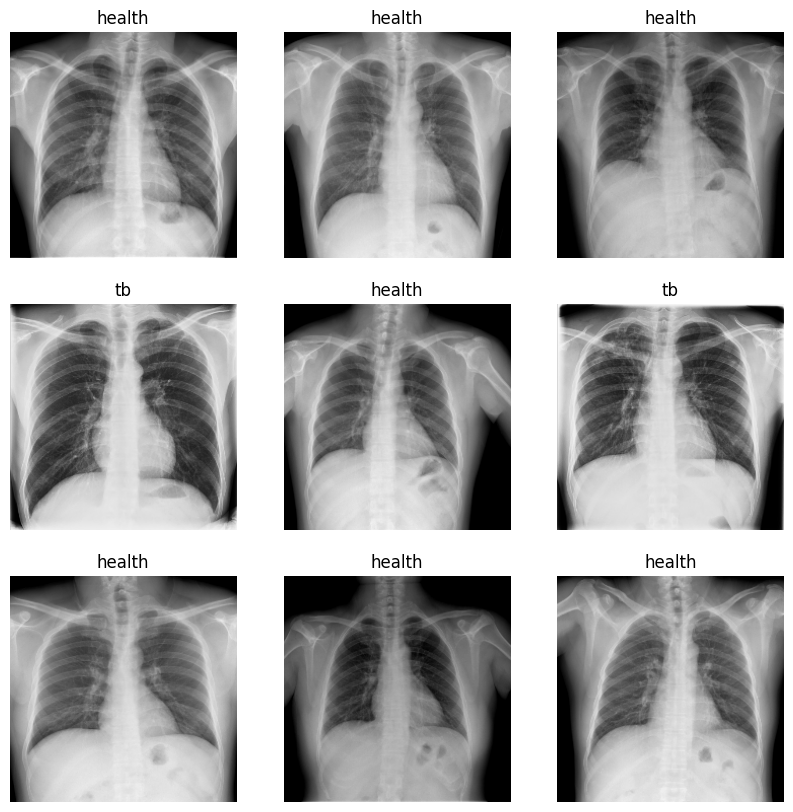

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_idx = int(labels[i].numpy()[0])
        plt.title(class_names[label_idx])
        plt.axis("off")
plt.show()

In [56]:
import tensorflow as tf
import numpy as np


test_image_path = sample_path

img = tf.keras.utils.load_img(test_image_path, target_size=IMG_SIZE)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

predictions = model.predict(img_array)
score = predictions[0][0]

predicted_class = class_names[1] if score > 0.5 else class_names[0]
confidence = score if score > 0.5 else 1 - score

print(f"Path File  : {test_image_path}")
print(f"Prediksi   : {predicted_class}")
print(f"Confidence : {confidence * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
Path File  : /root/.cache/kagglehub/datasets/usmanshams/tbx-11/versions/1/TBX11K/imgs/tb/tb0532.png
Prediksi   : tb
Confidence : 91.79%
